In [17]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from itertools import combinations  
from math import comb             

############
# parameters
############

N_arr = np.arange(2, 20, 2)
nmax = 100
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.1)

######################
# collective operators
######################

def collective_ops(N):
    sp, sm, I = qt.sigmap(), qt.sigmam(), qt.qeye(2)
    Sp = qt.jmat(N/2,'+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2,'z')
    HB = Sz+N/2*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    IB = qt.qeye(N+1)
    H = ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm))

    return H, HB

################
# Passive state
################

def passive_state(rho, H):
    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]          # decending order
    r_val = r_val[idx]

    e_val, e_vec = H.eigenstates()          # ascending order

    return np.sum(r_val[i] * e_vec[i] * e_vec[i].dag()
               for i in range(len(r_val)))

    
########################
# ergotropy calculation
########################

def ergotropy(ρ, H):
    ρ_p = passive_state(ρ, H)
    return qt.expect(H, ρ) - qt.expect(H, ρ_p)


################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, 0)  
    return qt.tensor(psiA, psiB)


##############
# Pnm matrix
##############

def pnm_matrix(rho, H):

    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = np.sum(r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2)

    return pnm, r_val, e_val
    

############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2


def dicke_state(N, k):
    dim = 2**N
    state = np.zeros(dim, dtype=complex)

    for positions in combinations(range(N), k):
        bits = [0]*N
        for p in positions:
            bits[p] = 1

        idx = int("".join(map(str, bits)), 2)
        state[idx] += 1

    state /= np.sqrt(comb(N, k))

    return qt.Qobj(state.reshape(-1, 1), dims=[[2]*N, [1]*N])


def projection_matrix(N):
    dicke_states = [dicke_state(N, k) for k in range(N+1)]

    P = qt.Qobj(np.hstack([d.full() for d in dicke_states]),dims=[[2]*N, [N+1]])
    
    return P

###############################
# Density Matrix in Full space 
###############################

def rho_full_from_sym(rho_sym, N):
    P = projection_matrix(N)
    rho_full = P * rho_sym * P.dag()

    return rho_full

In [15]:
import numpy as np
import qutip as qt
from itertools import combinations
from math import comb

########################
# Full Dicke state (2^N)
########################
def dicke_state(N, k):
    dim = 2**N
    state = np.zeros(dim, dtype=complex)

    for positions in combinations(range(N), k):
        bits = [0]*N
        for p in positions:
            bits[p] = 1

        idx = int("".join(map(str, bits)), 2)
        state[idx] += 1

    state /= np.sqrt(comb(N, k))

    return qt.Qobj(state.reshape(-1, 1), dims=[[2]*N, [1]*N])


########################
# Projection matrix
########################
def projection_matrix(N):
    dicke_states = [dicke_state(N, k) for k in range(N+1)]
    P = qt.Qobj(np.hstack([d.full() for d in dicke_states]),
                dims=[[2]*N, [N+1]])
    return P


########################
# Verify equivalence
########################
def verify_mapping(N):
    P = projection_matrix(N)

    print(f"\nN = {N}")
    for k in range(N+1):

        # Full Dicke state
        psi_full = dicke_state(N, k)

        # Project to symmetric basis
        psi_sym_from_full = P.dag() * psi_full

        # Direct symmetric basis state
        psi_sym_direct = qt.basis(N+1, k)

        # Compute overlap
        overlap = abs(psi_sym_direct.dag() * psi_sym_from_full)

        print(f"k = {k} → overlap = {overlap:.6f}")


########################
# Run test
########################
verify_mapping(20)


N = 20
k = 0 → overlap = 1.000000
k = 1 → overlap = 1.000000
k = 2 → overlap = 1.000000
k = 3 → overlap = 1.000000
k = 4 → overlap = 1.000000
k = 5 → overlap = 1.000000
k = 6 → overlap = 1.000000
k = 7 → overlap = 1.000000
k = 8 → overlap = 1.000000
k = 9 → overlap = 1.000000
k = 10 → overlap = 1.000000
k = 11 → overlap = 1.000000
k = 12 → overlap = 1.000000
k = 13 → overlap = 1.000000
k = 14 → overlap = 1.000000
k = 15 → overlap = 1.000000
k = 16 → overlap = 1.000000
k = 17 → overlap = 1.000000
k = 18 → overlap = 1.000000
k = 19 → overlap = 1.000000
k = 20 → overlap = 1.000000


N= 2, τ=0.010, E_B=2.000
N= 4, τ=0.010, E_B=4.000
N= 6, τ=0.010, E_B=6.000
N= 8, τ=0.010, E_B=8.000
N=10, τ=0.010, E_B=10.000
N=12, τ=0.010, E_B=12.000
N=14, τ=0.010, E_B=14.000
N=16, τ=0.010, E_B=16.000
N=18, τ=0.010, E_B=18.000
N=20, τ=0.010, E_B=20.000
N=22, τ=0.010, E_B=22.000


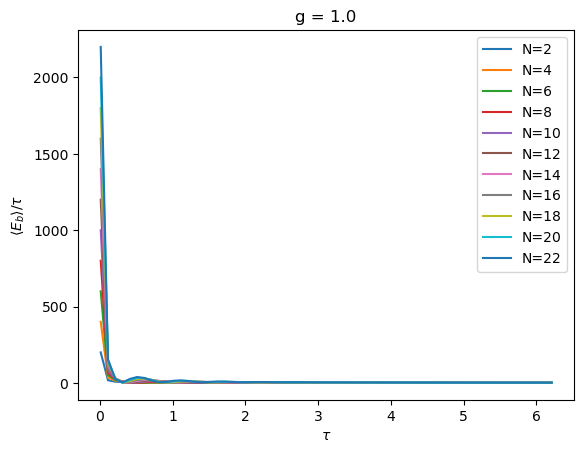

In [2]:

##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################
τ_list = []

for N in N_arr:

    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    HB_full = qt.tensor(qt.qeye(nmax), HB)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB_full)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.3f}, E_B={Eb_list[idx]:.3f}")
    
    ##################################
    # Plot of battery energy with time
    ##################################
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

In [ ]:
Eb_list = []
erg_list = []
var_list = []
ratio_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ])

    # Full density matrix at τ
    ρ_full = result.states[-1].proj()

    # Partial trace over cavity (subsystem 0)
    ρb = ρ_full.ptrace(1)

    ρ_b_full = rho_full_from_sym(ρb, N)

    P = projection_matrix(N)

    HB_full = P * HB * P.dag()

    Eb = qt.expect(HB_full, ρ_b_full)
    
    pnm, r_val, e_val = pnm_matrix(ρ_b_full, HB_full)

    # Ergotropy via pnm matrix
    erg = ergotropy_pnm(pnm, r_val, e_val)

    # Variance via pnm matrix
    var = variance_pnm(pnm, r_val, e_val)

    ratio = erg/Eb

    print(f"N={N:2d}, τ={τ:.3f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)

Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list)
var_arr = np.array(var_list)

rel_fluct = np.sqrt(var_arr) / erg_arr

rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

N= 2, τ=0.010, Eb=1.999400, Ergotropy=1.999400, erg/Eb=0.999999990003 Variance=5.9996647163e-04
N= 4, τ=0.010, Eb=3.998000, Ergotropy=3.998000, erg/Eb=1.000000000000 Variance=1.9998925762e-03
N= 6, τ=0.010, Eb=5.995800, Ergotropy=5.995800, erg/Eb=1.000000000000 Variance=4.2005569175e-03
N= 8, τ=0.010, Eb=7.992801, Ergotropy=7.992801, erg/Eb=1.000000000000 Variance=7.2023376491e-03
N=10, τ=0.010, Eb=9.989001, Ergotropy=9.989001, erg/Eb=1.000000000004 Variance=1.1005711943e-02
N=12, τ=0.010, Eb=11.984402, Ergotropy=11.984402, erg/Eb=0.999999999989 Variance=1.5611155776e-02
